In [1]:
!pip install nltk scikit-learn joblib

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import joblib

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [1]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import joblib

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
fake_df = pd.read_csv("/content/drive/MyDrive/fakenews dataset/fakenewszipfile/Fake.csv")
true_df = pd.read_csv("/content/drive/MyDrive/fakenews dataset/fakenewszipfile/True.csv")

In [4]:

print("Fake Dataset")
display(fake_df.head())

print("True Dataset")
display(true_df.head())

Fake Dataset


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


True Dataset


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [5]:
# Add labels
fake_df["label"] = 0   # Fake News
true_df["label"] = 1   # Real News

print(fake_df[["label"]].head())
print(true_df[["label"]].head())

   label
0      0
1      0
2      0
3      0
4      0
   label
0      1
1      1
2      1
3      1
4      1


In [6]:
# Combine datasets
df = pd.concat([fake_df, true_df], ignore_index=True)

# Shuffle the data
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (44898, 5)


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [7]:
print(df.isnull().sum())

title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [8]:
df = df.dropna()

In [9]:
df["content"] = df["title"] + " " + df["text"]

df = df[["content", "label"]]

display(df.head())

,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,1


In [11]:
ps = PorterStemmer()
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [ps.stem(word) for word in words if word not in stop_words]

    return " ".join(words)

df["content"] = df["content"].apply(clean_text)

display(df.head())

,content,label
0,ben stein call th circuit court commit coup dt...,0
1,trump drop steve bannon nation secur council w...,1
2,puerto rico expect us lift jone act ship restr...,1
3,oop trump accident confirm leak isra intellig ...,0
4,donald trump head scotland reopen golf resort ...,1


In [12]:
# Features (X) and Labels (y)
X = df["content"]
y = df["label"]

# Split into Training and Testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (35918,)
Testing Data: (8980,)


In [13]:
# Convert text to numerical features
vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

print("Training Matrix Shape:", X_train.shape)
print("Testing Matrix Shape:", X_test.shape)

Training Matrix Shape: (35918, 5000)
Testing Matrix Shape: (8980, 5000)


In [14]:
# Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

print("✅ Model Trained Successfully!")

✅ Model Trained Successfully!


In [15]:
# Make predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 98.64%


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4710
           1       0.98      0.99      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [18]:
joblib.dump(model, "fake_news_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print(" Model Saved Successfully!")

 Model Saved Successfully!


In [21]:
news = input("Enter a news article: ")

news = clean_text(news)

news_vector = vectorizer.transform([news])

prediction = model.predict(news_vector)

if prediction[0] == 0:
    print("🟥 Fake News")
else:
    print("🟩 Real News")

Enter a news article: today is holiday
🟥 Fake News


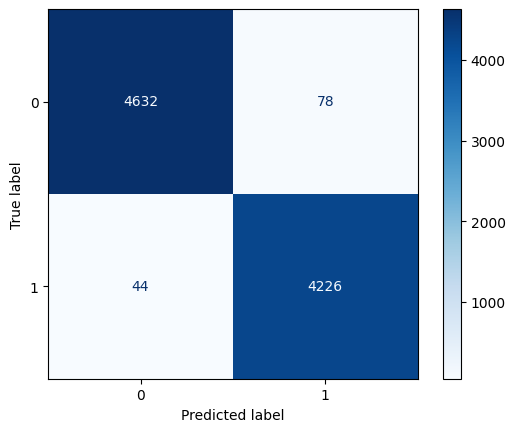

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

In [23]:
import joblib

joblib.dump(model, "/content/drive/MyDrive/fake_news_model.pkl")
joblib.dump(vectorizer, "/content/drive/MyDrive/tfidf_vectorizer.pkl")

['/content/drive/MyDrive/tfidf_vectorizer.pkl']